In [1]:
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve 

#### Loading Models

In [2]:
x_test_scaled=joblib.load('data/processed/x_test_scaled.pkl')
x_test=joblib.load('data/processed/x_test.pkl')
x_train_scaled_smote=joblib.load('data/processed/x_train_scaled_smote.pkl')
x_train_smote=joblib.load('data/processed/x_train_smote.pkl')
y_test=joblib.load('data/processed/y_test.pkl')
y_train_smote=joblib.load('data/processed/y_train_smote.pkl')

In [3]:
models = {
    "logistic_regression": LogisticRegression(),
    "Decision_Tree": DecisionTreeClassifier(),
    "Random_Forest": RandomForestClassifier(),
    "Gradient_Boost": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "XGBoost": XGBClassifier()
}

In [4]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

for name in models.keys():

    # load model
    model = joblib.load(
        f'models/{name}.pkl'
    )

    print(f"{name} Model Loaded Successfully")

    # Logistic Regression uses scaled data
    if name == "logistic_regression":

        y_train_pred = model.predict(
            x_train_scaled_smote
        )

        y_test_pred = model.predict(
            x_test_scaled
        )

    # Tree models use unscaled data
    else:

        y_train_pred = model.predict(
            x_train_smote
        )

        y_test_pred = model.predict(
            x_test
        )

    # Training Metrics
    train_accuracy = accuracy_score(
        y_train_smote,
        y_train_pred
    )

    train_f1 = f1_score(
        y_train_smote,
        y_train_pred
    )

    train_precision = precision_score(
        y_train_smote,
        y_train_pred
    )

    train_recall = recall_score(
        y_train_smote,
        y_train_pred
    )

    train_roc_auc = roc_auc_score(
        y_train_smote,
        y_train_pred
    )

    # Testing Metrics
    test_accuracy = accuracy_score(
        y_test,
        y_test_pred
    )

    test_f1 = f1_score(
        y_test,
        y_test_pred
    )

    test_precision = precision_score(
        y_test,
        y_test_pred
    )

    test_recall = recall_score(
        y_test,
        y_test_pred
    )

    test_roc_auc = roc_auc_score(
        y_test,
        y_test_pred
    )

    # Print Results
    print("=" * 50)

    print(f"{name} Performance")

    print("-" * 50)

    print("Training Performance")

    print(f"Accuracy : {train_accuracy:.4f}")
    print(f"F1 Score : {train_f1:.4f}")
    print(f"Precision: {train_precision:.4f}")
    print(f"Recall   : {train_recall:.4f}")
    print(f"ROC AUC  : {train_roc_auc:.4f}")

    print("-" * 50)

    print("Testing Performance")

    print(f"Accuracy : {test_accuracy:.4f}")
    print(f"F1 Score : {test_f1:.4f}")
    print(f"Precision: {test_precision:.4f}")
    print(f"Recall   : {test_recall:.4f}")
    print(f"ROC AUC  : {test_roc_auc:.4f}")

    print("=" * 50)
    print("\n")

logistic_regression Model Loaded Successfully
logistic_regression Performance
--------------------------------------------------
Training Performance
Accuracy : 0.6760
F1 Score : 0.6695
Precision: 0.6831
Recall   : 0.6565
ROC AUC  : 0.6760
--------------------------------------------------
Testing Performance
Accuracy : 0.6848
F1 Score : 0.4772
Precision: 0.3746
Recall   : 0.6573
ROC AUC  : 0.6749


Decision_Tree Model Loaded Successfully
Decision_Tree Performance
--------------------------------------------------
Training Performance
Accuracy : 0.9994
F1 Score : 0.9994
Precision: 0.9997
Recall   : 0.9991
ROC AUC  : 0.9994
--------------------------------------------------
Testing Performance
Accuracy : 0.6942
F1 Score : 0.4109
Precision: 0.3552
Recall   : 0.4874
ROC AUC  : 0.6198


Random_Forest Model Loaded Successfully
Random_Forest Performance
--------------------------------------------------
Training Performance
Accuracy : 0.9994
F1 Score : 0.9994
Precision: 0.9992
Recall   : 0.9

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression | 0.6848 | 0.3746 | **0.6573** | 0.4772 | 0.6749 |
| Decision Tree | 0.6942 | 0.3552 | 0.4874 | 0.4109 | 0.6198 |
| Random Forest | **0.7847** | **0.5082** | 0.4966 | **0.5023** | 0.6810 |
| Gradient Boost | 0.7565 | 0.4540 | 0.5560 | 0.4998 | 0.6843 |
| AdaBoost | 0.7322 | 0.4216 | 0.6017 | 0.4958 | **0.6852** |
| XGBoost | 0.7625 | 0.4579 | 0.4638 | 0.4608 | 0.6550 |
# Model Selection Conclusion

Multiple machine learning models were evaluated for predicting credit card default risk, including Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, AdaBoost, and XGBoost.

Since the dataset is imbalanced and the business objective focuses on identifying potential defaulters, model evaluation was not based solely on Accuracy. Greater importance was given to Recall, F1-score, ROC-AUC score, and the overall balance between correctly identifying risky customers while minimizing excessive false positive predictions.

---

## Logistic Regression

Logistic Regression achieved the highest Recall among all evaluated models, indicating strong capability in identifying defaulters. However, its Precision and F1-score were comparatively lower, meaning that a large number of non-defaulters were incorrectly classified as risky customers. While the model performed well in detecting defaults, the high false positive rate reduced its practical business applicability.

---

## Decision Tree

Decision Tree showed signs of overfitting, with significantly stronger training performance compared to testing performance. Although the model captured patterns effectively on the training dataset, its generalization capability on unseen data was comparatively weaker.

---

## Random Forest

Random Forest demonstrated the best overall balance across evaluation metrics. The model achieved:

- Highest Accuracy
- Highest Precision
- Highest F1-score
- Competitive Recall
- Strong ROC-AUC performance

The higher Precision indicates that the model generated fewer false positive predictions compared to other models, while still maintaining good capability in identifying defaulters.

Additionally, Random Forest showed stable and reliable performance on unseen test data, making it more suitable for real-world credit risk prediction scenarios.

---

## Gradient Boosting and AdaBoost

Both Gradient Boosting and AdaBoost produced balanced performance and competitive Recall values. AdaBoost, in particular, achieved strong ROC-AUC performance. However, their overall balance between Precision, Recall, and F1-score remained slightly below Random Forest.

---

## XGBoost

Although XGBoost is generally considered a powerful ensemble algorithm, its performance in this project was comparatively lower than Random Forest across several important metrics, including Recall, F1-score, and ROC-AUC score.

This may be attributed to the use of default hyperparameters and the interaction between SMOTE-based oversampling and the boosting mechanism. The untuned XGBoost model was unable to outperform Random Forest on the given dataset.

---

# Final Model Selection

After evaluating all models, **Random Forest** was selected as the final model for deployment.

The decision was based on its strong overall classification capability, balanced business-oriented performance, high Precision, highest F1-score, and reliable Recall performance.

The model provides an effective balance between:

- Correctly identifying risky customers
- Minimizing false alarms
- Maintaining strong overall predictive performance

Therefore, Random Forest was considered the most suitable model for the credit default prediction system.

# Hyperparameter Tunning

In [5]:
## Hyperparameter Training
rf_params = {"max_depth": [5, 8, 15, None, 10],
             "max_features": [5, 7, "auto", 8],
             "min_samples_split": [2, 8, 15, 20],
             "n_estimators": [100, 200, 500, 1000]}


# Models list for Hyperparameter tuning
randomcv_models = [
                   
                   ("Random_Forest",RandomForestClassifier(),rf_params)
                   
                   ]

In [6]:
from sklearn.model_selection import RandomizedSearchCV

model_param = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                   param_distributions=params,
                                   n_iter=20,
                                   cv=3,
                                   verbose=2,
                                   n_jobs=-1)
    random.fit(x_train_scaled_smote, y_train_smote)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 20 candidates, totalling 60 fits


d:\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
12 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "d:\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\anaconda3\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "d:\anaconda3\Lib\site-packages\sklearn\base.py", line 471, in _validate_params
    validate_parameter_constraints(
    ~~~~~~~~~~~~~

---------------- Best Params for Random_Forest -------------------
{'n_estimators': 1000, 'min_samples_split': 15, 'max_features': 7, 'max_depth': 15}


In [9]:
## Training the model using the best parameter an evaluating the metric scores.
from sklearn.ensemble import  RandomForestClassifier

rf=RandomForestClassifier(n_estimators=1000, min_samples_split= 15, max_features= 7, max_depth= 15)

In [10]:
rf.fit(x_train_smote,y_train_smote)

,n_estimators,1000
,criterion,'gini'
,max_depth,15
,min_samples_split,15
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,7
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
y_train_pred = rf.predict(
            x_train_smote
        )

y_test_pred = rf.predict(
            x_test
        )

    # Training Metrics
train_accuracy_tunned = accuracy_score(
        y_train_smote,
        y_train_pred
    )

train_f1_tunned = f1_score(
        y_train_smote,
        y_train_pred
    )

train_precision_tunned = precision_score(
        y_train_smote,
        y_train_pred
    )

train_recall_tunned = recall_score(
        y_train_smote,
        y_train_pred
    )

train_roc_auc_tunned = roc_auc_score(
        y_train_smote,
        y_train_pred
    )

    # Testing Metrics
test_accuracy_tunned = accuracy_score(
        y_test,
        y_test_pred
    )

test_f1_tunned = f1_score(
        y_test,
        y_test_pred
    )

test_precision_tunned = precision_score(
        y_test,
        y_test_pred
    )

test_recall_tunned = recall_score(
        y_test,
        y_test_pred
    )
test_roc_auc_tunned = roc_auc_score(
        y_test,
        y_test_pred
    )

    # Print Results
print("=" * 50)

print(f"{name} Performance")

print("-" * 50)

print("Training Performance")

print(f"Accuracy_tunned : {train_accuracy_tunned:.4f}")
print(f"F1_Score_tunned: {train_f1_tunned:.4f}")
print(f"Precision_tunned: {train_precision_tunned:.4f}")
print(f"Recall_tunned  : {train_recall_tunned:.4f}")
print(f"ROC_AUC_tunned  : {train_roc_auc_tunned:.4f}")

print("-" * 50)
print("Testing Performance")

print(f"Accuracy_tunned : {test_accuracy_tunned:.4f}")
print(f"F1_Score_tunned : {test_f1_tunned:.4f}")
print(f"Precision_tunned: {test_precision_tunned:.4f}")
print(f"Recall_tunned   : {test_recall_tunned:.4f}")
print(f"ROC_AUC_tunned  : {test_roc_auc_tunned:.4f}")

print("=" * 50)
print("\n")

Random_Forest Performance
--------------------------------------------------
Training Performance
Accuracy_tunned : 0.9028
F1_Score_tunned: 0.9005
Precision_tunned: 0.9220
Recall_tunned  : 0.8800
ROC_AUC_tunned  : 0.9028
--------------------------------------------------
Testing Performance
Accuracy_tunned : 0.7767
F1_Score_tunned : 0.5148
Precision_tunned: 0.4907
Recall_tunned   : 0.5415
ROC_AUC_tunned  : 0.6920




In [20]:
## Analysising the base model
from sklearn.ensemble import RandomForestClassifier
rf_base=RandomForestClassifier()
rf_base.fit(x_train_smote,y_train_smote)
y_train_pred = rf_base.predict(
            x_train_smote
        )

y_test_pred = rf_base.predict(
            x_test
        )

    # Training Metrics
train_accuracy_base = accuracy_score(
        y_train_smote,
        y_train_pred
    )

train_f1_base = f1_score(
        y_train_smote,
        y_train_pred
    )

train_precision_base = precision_score(
        y_train_smote,
        y_train_pred
    )

train_recall_base = recall_score(
        y_train_smote,
        y_train_pred
    )

train_roc_auc_base = roc_auc_score(
        y_train_smote,
        y_train_pred
    )

    # Testing Metrics
test_accuracy_base = accuracy_score(
        y_test,
        y_test_pred
    )

test_f1_base = f1_score(
        y_test,
        y_test_pred
    )

test_precision_base = precision_score(
        y_test,
        y_test_pred
    )

test_recall_base = recall_score(
        y_test,
        y_test_pred
    )
test_roc_auc_base = roc_auc_score(
        y_test,
        y_test_pred
    )

    # Print Results
print("=" * 50)

print(f"{name} Performance")

print("-" * 50)

print("Training Performance")

print(f"Accuracy_base : {train_accuracy_base:.4f}")
print(f"F1_Score_base: {train_f1_base:.4f}")
print(f"Precision_base: {train_precision_base:.4f}")
print(f"Recall_base  : {train_recall_base:.4f}")
print(f"ROC_AUC_base  : {train_roc_auc_base:.4f}")

print("-" * 50)
print("Testing Performance")

print(f"Accuracy_base : {test_accuracy_base:.4f}")
print(f"F1_Score_base : {test_f1_base:.4f}")
print(f"Precision_base: {test_precision_base:.4f}")
print(f"Recall_base   : {test_recall_base:.4f}")
print(f"ROC_AUC_base  : {test_roc_auc_base:.4f}")

print("=" * 50)
print("\n")

Random_Forest Performance
--------------------------------------------------
Training Performance
Accuracy_base : 0.9994
F1_Score_base: 0.9994
Precision_base: 0.9993
Recall_base  : 0.9996
ROC_AUC_base  : 0.9994
--------------------------------------------------
Testing Performance
Accuracy_base : 0.7825
F1_Score_base : 0.4888
Precision_base: 0.5032
Recall_base   : 0.4752
ROC_AUC_base  : 0.6719




### Comparing Performanance Metrics Using the test performance

In [22]:
import pandas as pd
comparison_df = pd.DataFrame(
    {

    "Metric": [
        "Accuracy",
        "F1 Score",
        "Precision",
        "Recall",
        "ROC-AUC"
    ],

    "Before Tuning": [

        test_accuracy_base,
        test_f1_base,
       test_precision_base,
        test_recall_base,
        test_roc_auc_base
    
    ],

    "After Tuning": [
test_accuracy_tunned,
        test_f1_tunned,
       test_precision_tunned,
        test_recall_tunned,
        test_roc_auc_tunned
    ]
}
)
print(comparison_df)

      Metric  Before Tuning  After Tuning
0   Accuracy       0.782500      0.776667
1   F1 Score       0.488837      0.514844
2  Precision       0.503226      0.490683
3     Recall       0.475248      0.541508
4    ROC-AUC       0.671910      0.692026


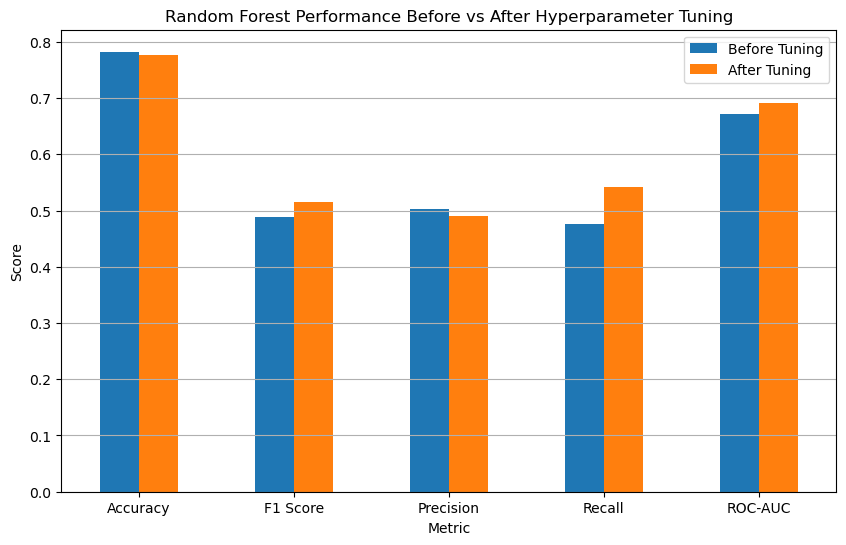

In [23]:
import matplotlib.pyplot as plt
comparison_df.set_index('Metric').plot(

    kind='bar',

    figsize=(10,6)

)

plt.title(
    'Random Forest Performance Before vs After Hyperparameter Tuning'
)

plt.ylabel('Score')

plt.xticks(rotation=0)

plt.grid(axis='y')

plt.show()

# Conclusion

Hyperparameter tuning improved the overall performance of the Random Forest model, particularly in terms of Recall, F1-score, and ROC-AUC score.

The Recall score increased significantly after tuning, indicating that the model became more effective at correctly identifying potential defaulters. This improvement is especially important for credit risk prediction, where failing to detect a defaulter may lead to financial losses for the bank.

The F1-score also improved after tuning, showing a better balance between Precision and Recall. Additionally, the ROC-AUC score increased, suggesting stronger overall classification capability and better separation between defaulters and non-defaulters.

Although Precision showed a slight decrease after tuning, the improvement in Recall was considered more important for this business problem due to the higher cost associated with false negatives.

Overall, hyperparameter tuning helped reduce overfitting and enhanced the generalization performance of the Random Forest model on unseen test data. Therefore, the tuned Random Forest model was selected as the final model for deployment in the credit default prediction system.